In [6]:
import importlib
import pandas as pd
import sys
sys.path.append(r'../src/')
import utils.order_book.order_book_impl as book_utils
import utils.order_book.utils as utils
import utils.order_book.graphic_utils as graph_utils

In [7]:
importlib.reload(book_utils)
importlib.reload(utils)
importlib.reload(graph_utils)
Order_book = book_utils.Order_book()
Order_book._generate_n_random_order(100)

Generating order book: 100%|██████████| 100/100 [00:00<00:00, 275.18it/s]


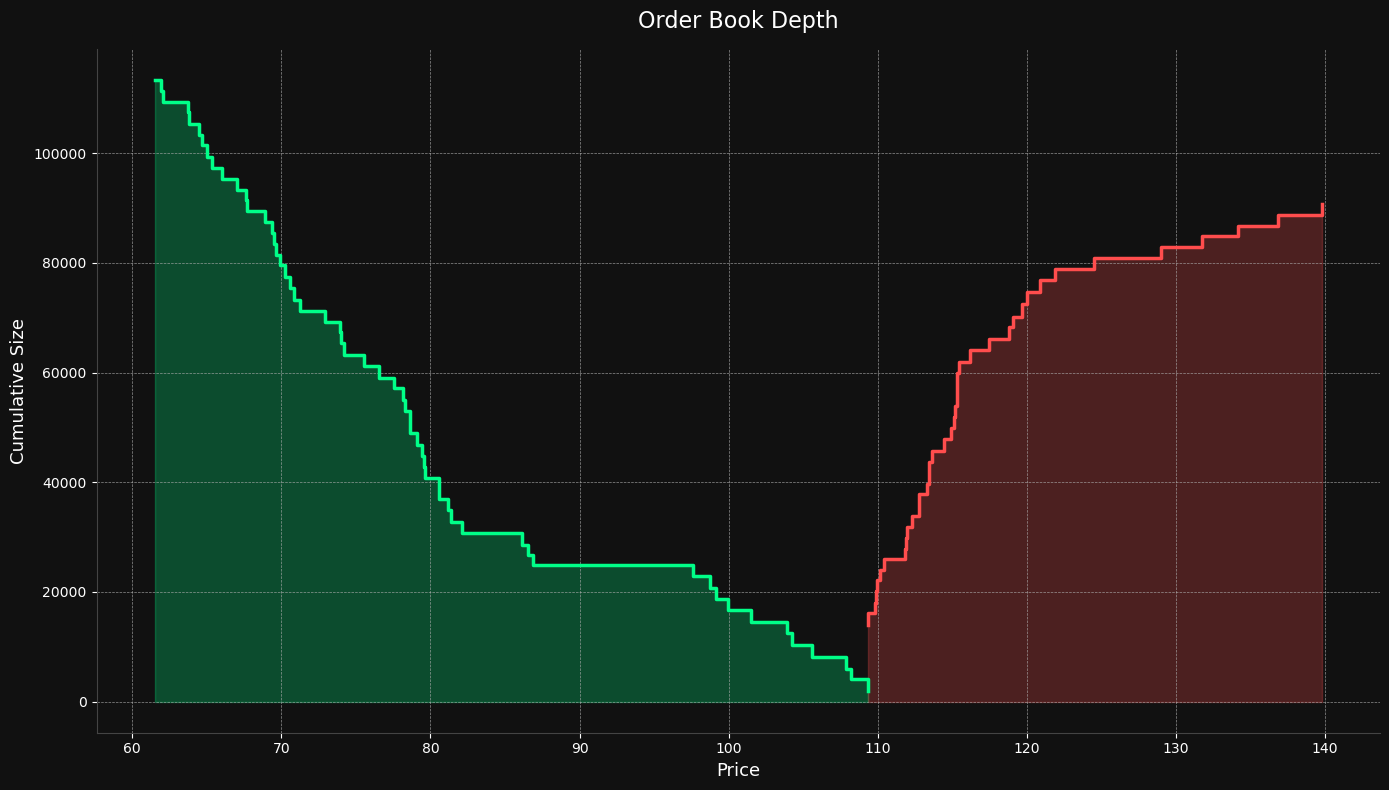

In [8]:
importlib.reload(book_utils)
graph_utils.plot_order_book(Order_book)

In [9]:
Order_book._df_bid_book

,Id,Price,Size,Type,Origin,Level,Time
1776277729754_1817,1776277729754_1817,99.9757,2102,limit_order,market_maker,0,2026-04-15 20:28:49.754
1776277729765_8271,1776277729765_8271,105.5574,2232,limit_order,market_maker,0,2026-04-15 20:28:49.765
1776277729769_2620,1776277729769_2620,104.2412,2259,limit_order,market_maker,0,2026-04-15 20:28:49.769
1776277729773_0061,1776277729773_0061,98.7663,2073,limit_order,market_maker,0,2026-04-15 20:28:49.773
1776277729783_1024,1776277729783_1024,99.1787,1979,limit_order,market_maker,0,2026-04-15 20:28:49.783
1776277729793_7647,1776277729793_7647,103.9366,2064,limit_order,market_maker,0,2026-04-15 20:28:49.793
1776277729797_8417,1776277729797_8417,107.8962,1859,limit_order,market_maker,0,2026-04-15 20:28:49.797
1776277729803_0899,1776277729803_0899,108.1736,2129,limit_order,market_maker,0,2026-04-15 20:28:49.803
1776277729806_8772,1776277729806_8772,109.3550,1922,limit_order,market_maker,0,2026-04-15 20:28:49.806
1776277729810_9886,1776277729810_9886,101.5013,2101,limit_order,market_maker,0,2026-04-15 20:28:49.810


Generating order book:   0%|          | 0/40 [00:00<?, ?it/s]

Generating order book: 100%|██████████| 40/40 [00:00<00:00, 206.15it/s]


MM book: 41 orders
  Bids: 19
  Asks: 22
  Best bid: 101.7793
  Best ask: 101.7794


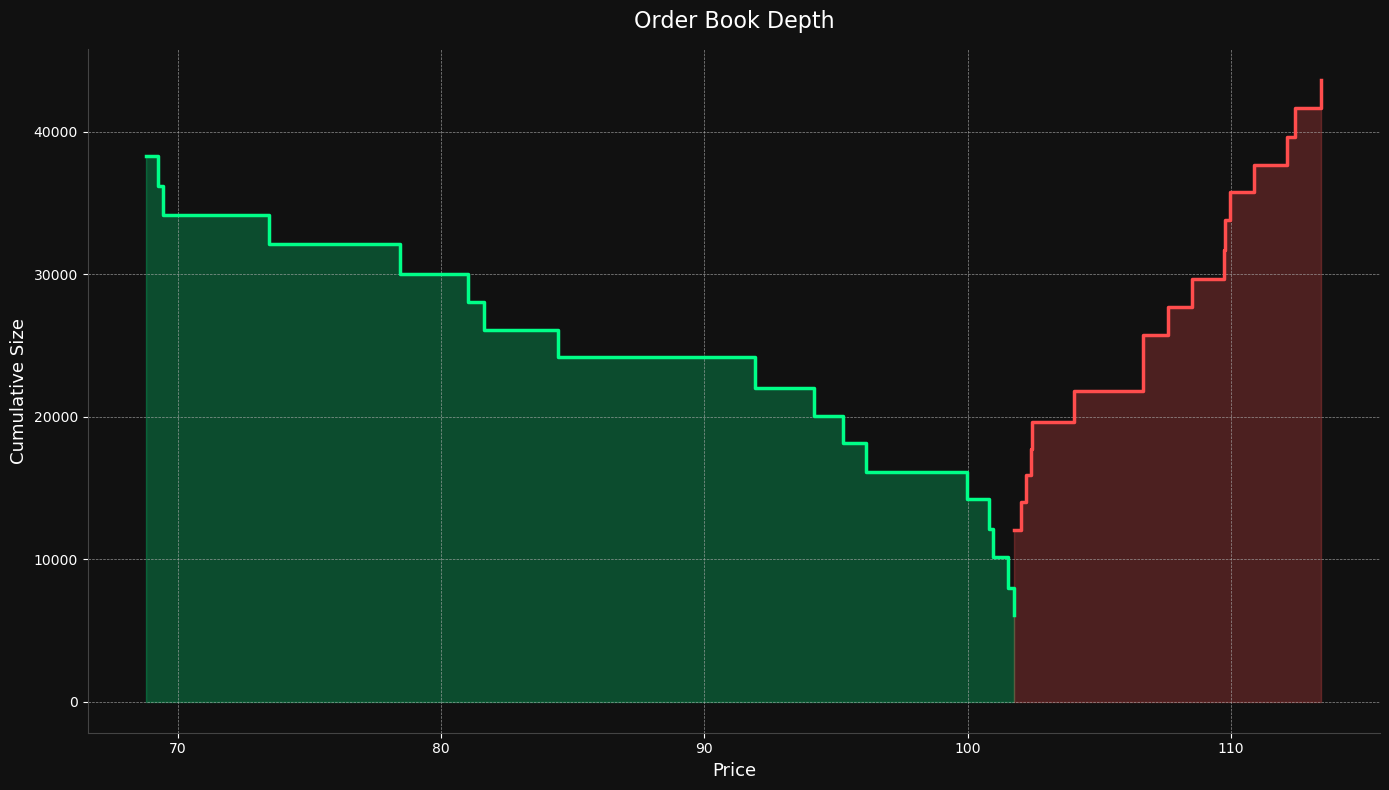

In [10]:
importlib.reload(book_utils)
importlib.reload(graph_utils)

ob = book_utils.Order_book()
ob._generate_n_random_order(40)

print(f"MM book: {len(ob._df_order_book)} orders")
print(f"  Bids: {(ob._df_order_book['Direction']=='buy').sum()}")
print(f"  Asks: {(ob._df_order_book['Direction']=='sell').sum()}")
print(f"  Best bid: {ob._df_order_book[ob._df_order_book['Direction']=='buy']['Price'].max():.4f}")
print(f"  Best ask: {ob._df_order_book[ob._df_order_book['Direction']=='sell']['Price'].min():.4f}")
graph_utils.plot_order_book(ob)

## Simulation

The market maker order book is now seeded. Key properties:
- All orders have `origin = "market_maker"`
- Bids and asks never cross (bid always < best ask)
- Prices generated via truncated normal distribution anchored on last price

Next steps:
1. **Generate client orders** with `generate_random_orders(n, origin="client")` — returns a list, does not touch the book
2. **Submit the batch** with `_add_orders_batch(orders)` — adds orders to the book
3. **Run clearing** with `try_clear()` — matches crossing orders (price-time priority, partial fills)
4. **Inspect matches** in `ob._df_matches` — client vs MM orders
5. **Cancel orders** to clean up the book after clearing

In [11]:
client_orders = ob.generate_random_orders(10, origin="client")
ob._add_orders_batch(client_orders)
ob.try_clear()

Adding orders: 100%|██████████| 10/10 [00:00<00:00, 587.74it/s]


In [12]:
ob._df_ask_book.sort_values("Price")

,Id,Price,Size,Type,Origin,Level,Time
1776277730558_5632,1776277730558_5632,101.7794,1831,limit_order,market_maker,0,2026-04-15 20:28:50.558
1776277730469_8704,1776277730469_8704,101.7794,2029,limit_order,market_maker,0,2026-04-15 20:28:50.469
1776277730477_2242,1776277730477_2242,101.7794,1952,limit_order,market_maker,0,2026-04-15 20:28:50.477
1776277730488_8106,1776277730488_8106,101.7794,1976,limit_order,market_maker,0,2026-04-15 20:28:50.488
1776277730505_1204,1776277730505_1204,101.7794,2254,limit_order,market_maker,0,2026-04-15 20:28:50.505
1776277730551_2954,1776277730551_2954,101.7794,1997,limit_order,market_maker,0,2026-04-15 20:28:50.551
1776277730499_4986,1776277730499_4986,102.0299,1975,limit_order,market_maker,0,2026-04-15 20:28:50.499
1776277730568_5227,1776277730568_5227,102.2109,1874,limit_order,market_maker,0,2026-04-15 20:28:50.568
1776277730753_8068,1776277730753_8068,102.2932,2255,limit_order,client,0,2026-04-15 20:28:50.753
1776277730509_6747,1776277730509_6747,102.4004,1879,limit_order,market_maker,0,2026-04-15 20:28:50.509


In [13]:
len(ob._df_ask_book)

25

In [14]:
client_orders = ob.generate_random_orders(10, origin="client")
ob._add_orders_batch(client_orders)
ob.try_clear()

print(f"Matches: {len(ob._df_matches)}")
ob._df_matches[["Direction", "Price", "MatchedSize", "ClientOrderId", "MmOrderId"]]

Adding orders: 100%|██████████| 10/10 [00:00<00:00, 714.76it/s]

Matches: 6


,Direction,Price,MatchedSize,ClientOrderId,MmOrderId
0,sell,101.7793,2011,1776277730761_4650,1776277730472_5705
1,sell,101.7793,56,1776277730763_3669,1776277730472_5705
2,sell,101.7793,1804,1776277730763_3669,1776277730481_2758
3,sell,101.7793,282,1776277730763_3669,1776277730485_9738
4,sell,101.7793,1926,1776277730757_3346,1776277730485_9738
5,sell,101.5267,19,1776277730757_3346,1776277730421_6288


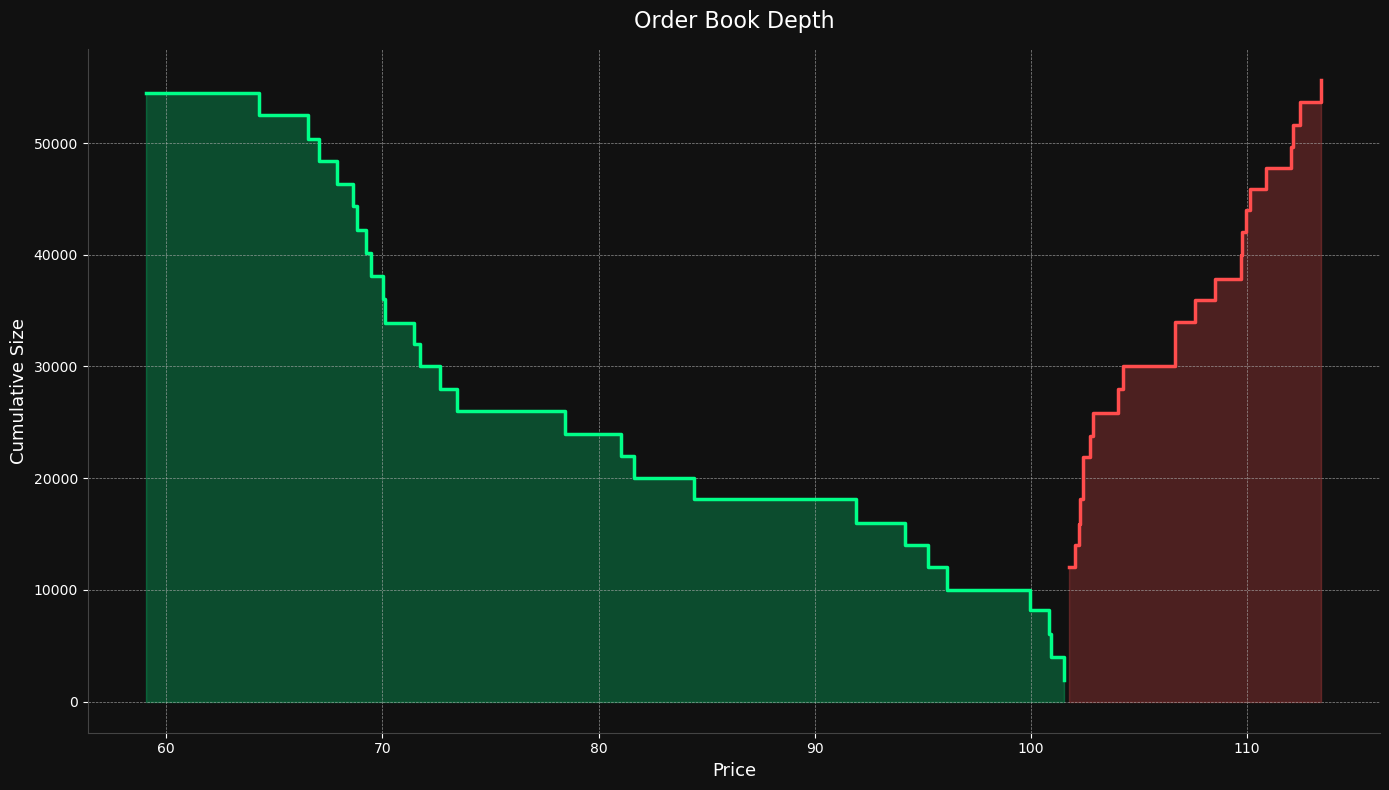

In [15]:
graph_utils.plot_order_book(ob)

In [16]:
if not ob._df_matches.empty:
    by_dir = ob._df_matches.groupby("Direction").agg(
        Matches=("MatchedSize", "count"),
        Volume=("MatchedSize", "sum"),
        AvgPrice=("Price", "mean"),
    )
    print(f"Total matched volume : {ob._df_matches['MatchedSize'].sum():,.0f}")
    print(f"Remaining open orders: {len(ob._df_order_book)}")
    print()
    print(by_dir)
else:
    print("No matches â€” client prices did not cross MM quotes (try re-running)")

Total matched volume : 6,098
Remaining open orders: 55

           Matches  Volume  AvgPrice
Direction                           
sell             6    6098  101.7372


In [17]:
# cancel specific orders by ID
some_ids = ob._df_order_book.index[:3].tolist()
print(f"Before cancel_orders: {len(ob._df_order_book)} orders")
ob.cancel_orders(some_ids)
print(f"After cancel_orders({len(some_ids)} ids): {len(ob._df_order_book)} orders")

# cancel all remaining MM orders
mm_count = (ob._df_order_book["Origin"] == "market_maker").sum()
ob.cancel_all_mm_orders()
print(f"After cancel_all_mm_orders ({mm_count} removed): {len(ob._df_order_book)} orders left")
print("Remaining orders (should be client-only):")
ob._df_order_book[["Direction", "Price", "Size", "Origin"]].head(10)

Before cancel_orders: 55 orders
After cancel_orders(3 ids): 52 orders
After cancel_all_mm_orders (35 removed): 17 orders left
Remaining orders (should be client-only):


,Direction,Price,Size,Origin
1776277730749_6004,buy,64.2872,2125,client
1776277730751_6952,sell,102.8728,2061,client
1776277730753_8068,sell,102.2932,2255,client
1776277730755_8633,buy,70.0274,2129,client
1776277730758_8239,buy,66.5623,1953,client
1776277730760_7724,sell,104.2517,2014,client
1776277730764_6584,buy,68.6487,2101,client
1776277730858_2190,sell,110.1491,1876,client
1776277730860_6948,buy,59.0851,1990,client
1776277730861_5983,buy,67.0688,2101,client
